In [205]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Introduction – degradation of a sorbing contaminant

To investigate the degradation of a chemical pollutant on contaminated soil, an experiment is conducted in a laboratory. 20 g of the contaminated soil are incubated with water. The concentration of the contaminant are monitored in the water over time.

The contaminant sorbs to the soil – that is, some of it sticks to the soil particles or grains.
The sorbed concentration $s$ equilibrates quickly with the concentration of the pollutant in the water $c$. The relationship between the two is non-linear:

$$s = K c^n$$

Therefore, the total mass of the contaminant in the system, $m$ is

$$m = c V + K c^n m_{\mathrm{soil}}$$

where $V$ is the water volume and $m_{\mathrm{soil}}$ the mass of the soil.

In addition, the pollutant is degraded according to a first-order rate law with coefficient $k$.
The mass balance for the pollutant therefore is:

$$\frac{dm}{dt} = \frac{dc}{dt} V + K  n c^{n-1} \frac{dc}{dt} m_{\mathrm{soil}} = -V k c$$

This can be rearranged into an ordinary differential equation (ODE) for the concentration in the water:

$$\frac{dc}{dt} = -\frac{1}{R(c)} kc$$

where $R(c) = 1 + \alpha nc^{n-1}$ is a concentration-dependent retardation factor and $\alpha = \frac{K m_{\mathrm{soil}}}{V}$.
Note that the retardation factor makes the ODE non-linear!
The Python functions below implement the right-hand-side of the ODE. 

In this assignment, you will numerically solve this ODE to simulate the concentration of the pollutant during the experiment. You will compare different numerical solution techniques, including the implicit Euler scheme.

In [206]:
def compute_retardation_factor(c, alpha, n):
    """
    Calculate the retardation factor based on the concentration, sorption coefficient, and exponent.

    Parameters:
    - c: concentration
    - alpha: sorption coefficient
    - n: exponent for the sorption isotherm

    Returns:
    - R: retardation factor
    """
    return 1 + alpha * n * c ** (n - 1)


def decay_model_with_sorption(t, c, k, n, alpha):
    """
    Defines the ODE for the decay model with sorption.

    Parameters:
    - t: time
    - c: concentration at time t
    - k: decay rate constant
    - n: exponent for the sorption isotherm
    - alpha: sorption coefficient

    Returns:
    - dc/dt: rate of change of concentration
    """
    return -k * c / compute_retardation_factor(c, alpha, n)

## Part 1: Implicit Euler scheme and Newton-Raphson method

> **Task 1.1:**
> Formulate the numerical expression for the given ODE using the implicit Euler scheme, in which the new (unknown) concentration is $c_{i+1}$.



> **Task 1.2:**
>
> To solve the discretized Euler scheme for non-linear functions, we apply the Newton-Raphson method to find the root of a function $g(z)$. What is $z$ for the given ODE? Provide an expression for g(z).


In the Newton-Raphson iterations, we obtain the new point as follows:

$$z_{j+1} = z_j - \frac{g(z_j)}{g^\prime(z_j)}$$

Applied to our model, this looks like this:

$$c_{i+1}^{j+1} = c_{i+1}^j - \frac{q(c_{i+1}^j)}{q^\prime(c_{i+1}^j)}$$

where $i$ is the index for the time step and $j$ is the index for the Newton-Raphson iteration.

> **Task 1.3:**
> 
> Fill in the code templates below to implement Python functions that evaluate $g(z)$ and $g^\prime(z)$.
> 
> Consider that $g^\prime(z) = q^\prime(c_{i+1}) = 1- \Delta t f^\prime(c_{i+1}, t_{i+1})$ and use the following derivative for the right-hand-side of the ODE:
> 
> $$f^\prime(c_{i+1}, t_{i+1}) = -k \left[\frac{1}{R(c_{i+1})} - \frac{\alpha n (n-1) {c_{i+1}}^{n-1}}{(R(c_{i+1}))^2}\right]$$
> 
> Tip: This expression is already provided in the code template below.

In [207]:
def evaluate_g(c_next, c_prev, t_next, dt, k, n, alpha):
    """Evaluate the function g of which to find the root in the Newton-Raphson iterations

    Parameters
    ----------
    c_next: concentration at time t_{i+1}
    c_prev: concentration at time t_i
    t_next: time t_{i+1}
    dt: time increment
    k, n,alpha: model parameters
    """
    return  c_next - dt*decay_model_with_sorption(t_next, c_next, k, n, alpha)   -c_prev


def evaluate_g_prime(c_next, t_next, dt, k, n, alpha):
    "Evaluate the derivative of g"
    retardation_factor = compute_retardation_factor(c_next, alpha, n)
    f_prime = -k * (
        1 / retardation_factor
        - alpha * n * (n - 1) * c_next ** (n - 1) / retardation_factor**2
    )
    return 1 -dt*f_prime

> **Task 1.4**
> 
> Fill in the code template below to implement the implicit Euler scheme with Newton-Raphson iterations for the model.

In [208]:
# Define model parameters
dist_coeff = (
    100  # distribution coefficient [L/kg] # TODO: check units due to the exponent
)
mass = 0.02  # mass of soil [kg]
volume = 0.1  # volume of water [L]
alpha = dist_coeff * mass / volume  # sorption coefficient
k = 0.5  # decay constant [1/day]
n = 0.5
c0 = 10.0  # initial concentration

In [209]:
# Set up initial condition and time vector
dt = 0.1
t_end = np.maximum(100, dt * 2)
times = np.arange(0, t_end, dt)  # in days
n_times = len(times)

# Define algorithm options
tolerance = 1e-3  # tolerance ϵ for the Newton-Raphson iterations
# maximum number of Newton-Raphson iterations (to prevent an infinite loop)
max_iter = 50

In [210]:
def solve_implicit_euler(c0, times, dt, k, n, alpha, tolerance=1e-3, max_iter=50):
    """
    Solve the decay model with sorption using the implicit Euler method.

    Parameters:
    - c0: initial concentration
    - times: array of time points
    - dt: time increment
    - k: decay rate constant
    - n: exponent for the sorption isotherm
    - alpha: sorption coefficient
    - tolerance: tolerance for Newton-Raphson iterations
    - max_iter: maximum number of Newton-Raphson iterations

    Returns:
    - c_array: array of concentrations at each time point
    """

    # Initialize a list to store the state
    c = [c0]

    # Initialize the current state
    c_prev =c0
    n_iter = []

    # Iterate over times
    for i in range(1, n_times):
        t_next = times[i]

        # Initialize Newton-Raphson iterations: start with the current value as a guess
        j = 0
        c_next = c_prev

        # Choose arbitrary large error to make sure we enter the Newton iterations at least once
        error = tolerance + 1
        ### YOUR CODE LINES HERE , done

        # Newton-Raphson iterations
        while error> tolerance and j < max_iter:
            g = evaluate_g(c_next, c_prev, t_next, dt, k, n, alpha)
            g_prime = evaluate_g_prime(c_next, t_next, dt, k, n, alpha)
            error = np.abs(g)

            ### YOUR CODE LINES HERE
            #updating c state
            c_next = c_next -g/g_prime
            j+=1          #next step has been defined

            if j>= max_iter:
                print("Reached MAX NR Iter's")
        n_iter.append(j)
        c.append(c_next)
        c_prev = c_next
        
    # Convert list of states to a numpy array
    c_array = np.array(c)
    return c_array

In [211]:
c_implicit = solve_implicit_euler(c0, times, dt, k, n, alpha, tolerance, max_iter)

> **Task 1.5**
> 
> Compare your solution to the reference solution below. The reference solution is created by running an accurate solver from the Scipy library. You can use it to evaluate your implementation. If you choose a small time step (0.1 days), and your implementation is correct, the solutions should look the same.

In [212]:
# Compute reference solution using scipy's solve_ivp
t_end = times[-1]
t_dense = np.linspace(0, t_end, 6000)
sol = solve_ivp(
    decay_model_with_sorption,
    t_span=(0, t_end),
    y0=np.array([c0]),
    t_eval=t_dense,
    args=(k, n, alpha),
    max_step=0.8,
    method="BDF",
)


(0.0, 10.492619811342376)

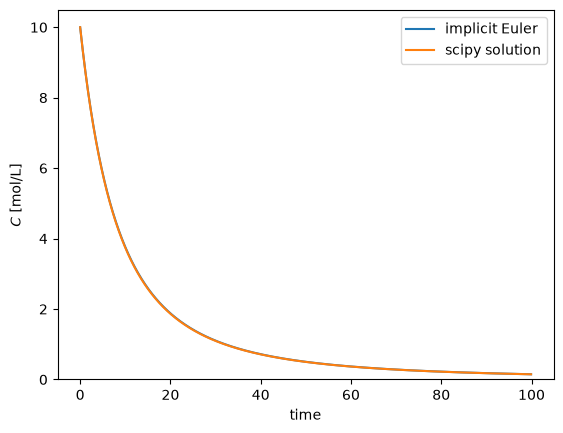

In [213]:
# Plot the implicit Euler solution against the reference solution
plt.plot(times, c_implicit, label="implicit Euler")
plt.plot(sol.t, sol.y[0], label="scipy solution")
plt.legend()
plt.xlabel("time")
plt.ylabel("$C$ [mol/L]")
plt.ylim(bottom=0)

## Part 2: Adams-Bashfort method


> **Task 2.1**
> 
> Fill in the code template below to implement a solution of the decay model with the Adams-Bashforth method.

In [232]:
def solve_adams_bashforth(c0, times, dt, k, n, alpha):
    """
    Solve the decay model with sorption using the Adams-Bashforth method.

    Parameters:
    - c0: initial concentration
    - times: array of time points
    - dt: time increment
    - k: decay rate constant
    - n: exponent for the sorption isotherm
    - alpha: sorption coefficient

    Returns:
    - c_array: array of concentrations at each time point
    """

    # Initialize a list to store the state
    c = [c0]

    # Initialize the current state
    c_i = c0


    c1 = c0

    # Iterate over times
    for i in range(0, len(times)-1 ):
        t_i = times[i]        

        #not self starting
        if i == 0:
            f0 = decay_model_with_sorption(times[0], c0, k, n, alpha)
            c_i_plus_1 = c0 + f0*dt
            c.append(c_i_plus_1)
        else:
            f_i = decay_model_with_sorption(times[i], c[i], k, n, alpha)         #step i defined
            f_im1 = decay_model_with_sorption(times[i-1], c[i-1], k, n, alpha)    #initial condition
        #new c
            c_next = c[i]+(dt/2)*(3*f_i-f_im1)
            c.append(c_next)
        ### YOUR CODE LINES HERE

    # Convert list of states to a numpy array
    c_array = np.array(c)
    return c_array

In [233]:
c_adams_bashforth = solve_adams_bashforth(c0, times, dt=dt, k=k, n=n, alpha=alpha)
c_adams_bashforth

array([ 1.00000000e+01+0.00000000e+00j, -8.01898050e+00+0.00000000e+00j,
        7.68767112e+00+2.36500022e+01j,  1.59531081e+01-8.09731841e+01j,
        9.03550684e+01+4.14173387e+02j,  7.36589392e+01-3.11872862e+03j,
        2.75201277e+03+2.88120753e+04j, -1.60161879e+04-2.92758714e+05j])

## Part 3: Numerical stability and accuracy

The code below compares the solution obtained with the implicit Euler scheme to the solution from the explicit Euler scheme and the reference solution.


In [234]:
def solve_explicit_euler(c0, times, dt, k, n, alpha):
    """
    Solve the decay model with sorption using the explicit Euler method.

    Parameters:
    - c0: initial concentration
    - times: array of time points
    - dt: time increment
    - k: decay rate constant
    - n: exponent for the sorption isotherm
    - alpha: sorption coefficient

    Returns:
    - c_array: array of concentrations at each time point
    """

    # Initialize a list to store the state
    c = [c0]

    # Initialize the current state
    c_prev = c0

    # Iterate over times
    for i in range(1, len(times)):
        t_next = times[i]
        # Explicit Euler update
        c_next = c_prev + dt * decay_model_with_sorption(t_next, c_prev, k, n, alpha)
        c.append(c_next)
        c_prev = c_next

    # Convert list of states to a numpy array
    c_array = np.array(c)
    return c_array

> **Task 3.1**
> 
> Run the code cell below that plots the solution obtained with the Adams-Bashforth method to the solution from the implicit and explicit Euler scheme (using the same time step size of $\Delta t = 2 \,\mathrm{d}$). Compare the accuracy of the Adams-Bashforth solution to the one from the Euler schemes.

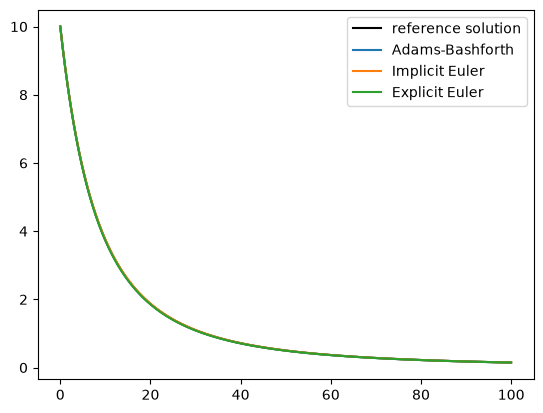

In [235]:
dt = 0.1
t_end = np.maximum(100, dt * 5)
times = np.arange(0, t_end + dt, dt)  # in days
n_times = len(times)

c_implicit = solve_implicit_euler(c0, times, dt, k, n, alpha, tolerance, max_iter)
c_adams_bashforth = solve_adams_bashforth(c0, times, dt=dt, k=k, n=n, alpha=alpha)

c_explicit = solve_explicit_euler(c0, times, dt, k, n, alpha)
plt.plot(sol.t, sol.y[0], label="reference solution", color="black")
plt.plot(times, c_adams_bashforth, label="Adams-Bashforth")
plt.plot(times, c_implicit, label="Implicit Euler")
plt.plot(times, c_explicit, label="Explicit Euler")
plt.legend()


> **Task 3.2**
> 
> Vary the time step in the code cell below, using values of 0.1 day, 5 day, 10 days, 15 days. Compare the behavior of the implicit and explicit Euler scheme and the Adams-Bashforth scheme at the different time step sizes.
> 
> Take notes about the results – you will need them for the report later on. You may also want to schematically sketch the plots (exact values are not important).

Text(0.5, 1.0, 'Solution for $\\Delta t = 5 \\,\\mathrm{d}$')

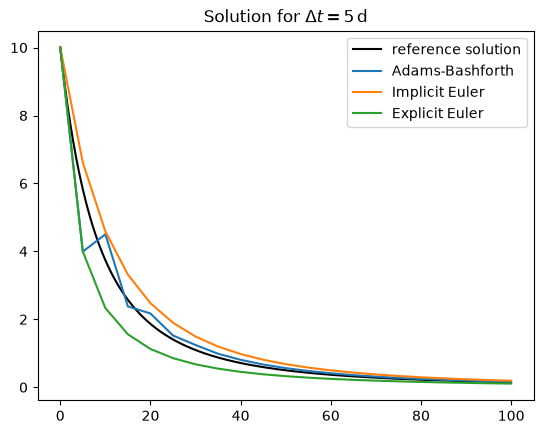

In [ ]:
dt = 5
t_end = np.maximum(100, dt * 5)
times = np.arange(0, t_end + dt, dt)  # in days
n_times = len(times)

c_adams_bashforth = solve_adams_bashforth(c0, times, dt=dt, k=k, n=n, alpha=alpha)
c_implicit = solve_implicit_euler(c0, times, dt, k, n, alpha, tolerance, max_iter)
c_explicit = solve_explicit_euler(c0, times, dt, k, n, alpha)
plt.plot(sol.t, sol.y[0], label="reference solution", color="black")
plt.plot(times, c_adams_bashforth, label="Adams-Bashforth")
plt.plot(times, c_implicit, label="Implicit Euler")
plt.plot(times, c_explicit, label="Explicit Euler")
plt.legend()
plt.title(fr"Solution for $\Delta t = {dt} \,\mathrm{{d}}$")

> By Anna Störiko and Ronald Brinkgreve, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).